 
## Stock market analysis system

## Ihsanullah


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

### Basic Info: 

In [17]:
df = pd.read_csv('Apple Stock Price History.csv')


df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,11/28/2025,278.85,277.26,279.00,275.99,20.14M,0.47%
1,11/26/2025,277.55,276.96,279.53,276.63,33.43M,0.21%
2,11/25/2025,276.97,275.27,280.38,275.25,46.91M,0.38%
3,11/24/2025,275.92,270.90,277.00,270.90,65.59M,1.63%
4,11/21/2025,271.49,265.95,273.33,265.67,59.03M,1.97%


### Initial Data Checking (EDA Inspection)

In [18]:
# Cell 2: Initial Data Inspection
print("--- Data Types and Info ---")
df.info()

print("\n--- Null Value Check ---")
null_counts = df.isnull().sum()
print(null_counts)

--- Data Types and Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1256 entries, 0 to 1255
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1256 non-null   object 
 1   Price     1256 non-null   float64
 2   Open      1256 non-null   float64
 3   High      1256 non-null   float64
 4   Low       1256 non-null   float64
 5   Vol.      1256 non-null   object 
 6   Change %  1256 non-null   object 
dtypes: float64(4), object(3)
memory usage: 68.8+ KB

--- Null Value Check ---
Date        0
Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64


In [19]:
print("\nNull Value Check:")
# Check for null values in each column
null_counts = df.isnull().sum()
print(null_counts)

cols_with_nulls = null_counts[null_counts > 0]
print(f"\nColumns with missing values: {list(cols_with_nulls.index)}")


Null Value Check:
Date        0
Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64

Columns with missing values: []


## Checking for Null values (if there are none then continue)

In [20]:
# Cell 3: Missing Value Imputation and Handling

# Cell 3: Missing Value Imputation and Handling (Robust for any column with NaNs)
cols_with_nulls = df.isnull().sum()[df.isnull().sum() > 0]

if cols_with_nulls.empty:
    print(" No missing values found. Skipping imputation.")
else:
    print(" Missing values detected. Applying imputation strategies...")
    
    # Impute numeric columns with the Median
    numeric_cols = df.select_dtypes(include=np.number).columns
    for col in numeric_cols:
        if col in cols_with_nulls.index:
            df[col].fillna(df[col].median(), inplace=True)

    # Impute object/string columns with Mode 
    object_cols = df.select_dtypes(include='object').columns
    for col in object_cols:
        if col in cols_with_nulls.index:
            df[col].fillna(df[col].mode()[0], inplace=True)

df.dropna(inplace=True)
print("\nTotal remaining null values after cleaning:", df.isnull().sum().sum())

 No missing values found. Skipping imputation.

Total remaining null values after cleaning: 0


In [21]:
df.describe()

,Price,Open,High,Low
count,1256.000000,1256.000000,1256.000000,1256.000000
mean,178.858949,178.669228,180.633822,176.901537
std,37.802271,37.733390,38.024971,37.516873
min,116.360000,116.970000,120.400000,116.210000
25%,148.172500,148.002500,149.440000,146.455000
50%,173.015000,172.775000,174.300000,171.330000
75%,207.632500,206.720000,210.040000,204.452500
max,278.850000,277.260000,280.380000,276.630000


##  Structural Data Cleaning and Sorting

In [22]:
print(df.columns)
print(df.index.name)


Index(['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %'], dtype='object')
None


In [23]:
# Cell 4: Structural Data Cleaning and Sorting (Robust for any dataset)

# --- 1. Handle Date column or index ---
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.sort_values('Date').reset_index(drop=True)
    df = df.set_index('Date')
    print(" 'Date' column converted to datetime and set as index.")
elif df.index.name and df.index.name.lower() == 'date':
    df.index = pd.to_datetime(df.index, errors='coerce')
    df = df.sort_index()
    print(" 'Date' index converted to datetime and sorted.")
else:
    print(" No 'Date' column or index found. Skipping date handling.")

# --- 2. Universal Cleaner for Volume column ---
def volume_to_numeric(vol):
    """Converts volume strings with 'M' or 'K' to floats."""
    if isinstance(vol, str):
        vol = vol.upper().replace(',', '')
        if 'M' in vol:
            return float(vol.replace('M', '')) * 1_000_000
        elif 'K' in vol:
            return float(vol.replace('K', '')) * 1_000
    return vol

if 'Vol.' in df.columns:
    df['Vol.'] = df['Vol.'].astype(str).apply(volume_to_numeric)
    df['Vol.'] = pd.to_numeric(df['Vol.'], errors='coerce')
    print(" 'Vol.' column cleaned and converted to numeric.")
else:
    print(" 'Vol.' column not found. Skipping volume cleaning.")

# --- 3. Clean 'Change %' column ---
if 'Change %' in df.columns:
    df['Change %'] = df['Change %'].astype(str).str.replace('%', '', regex=False)
    df['Change %'] = pd.to_numeric(df['Change %'], errors='coerce')
    print(" 'Change %' column cleaned and converted to numeric.")
else:
    print(" 'Change %' column not found. Skipping percentage cleaning.")

# --- 4. Final cleanup ---
df.dropna(inplace=True)
print(" Data cleaned and sorted. All relevant columns are numeric.")
df.info()


 'Date' column converted to datetime and set as index.
 'Vol.' column cleaned and converted to numeric.
 'Change %' column cleaned and converted to numeric.
 Data cleaned and sorted. All relevant columns are numeric.
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1256 entries, 2020-11-30 to 2025-11-28
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     1256 non-null   float64
 1   Open      1256 non-null   float64
 2   High      1256 non-null   float64
 3   Low       1256 non-null   float64
 4   Vol.      1256 non-null   float64
 5   Change %  1256 non-null   float64
dtypes: float64(6)
memory usage: 68.7 KB


## EDA:

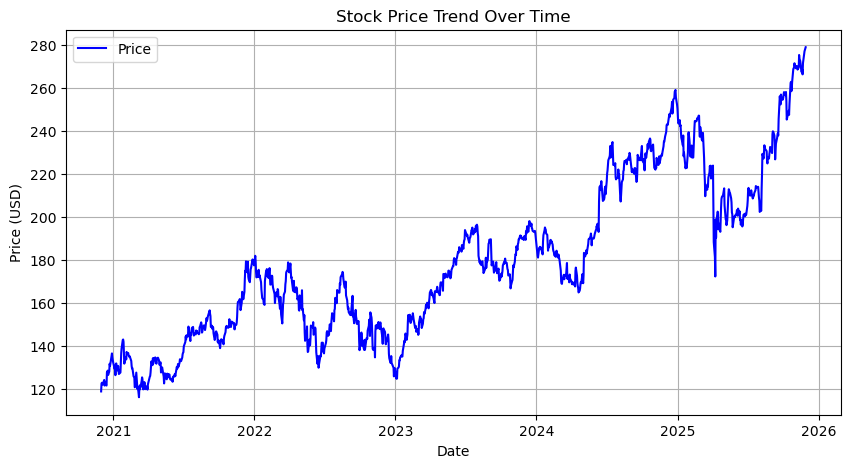

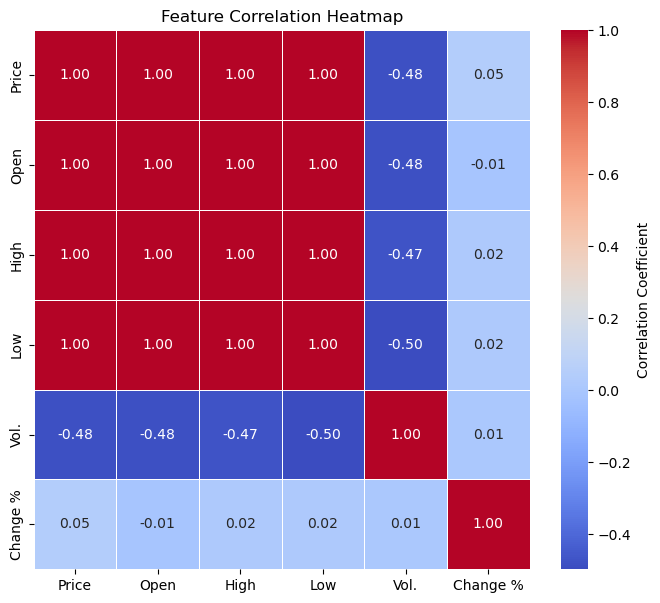

In [24]:
# Cell 5: EDA and Visualization (Heat Chart Requirement)

# Plot 1: Historical Price Trend
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Price'], label='Price', color='blue')
plt.title('Stock Price Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.legend()
plt.show()

# Plot 2: Correlation Heatmap
plt.figure(figsize=(8, 7))
corr_matrix = df.corr() 
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Feature Correlation Heatmap')
plt.show()

In [25]:
# Feature Engineering
PREDICT_DAYS = 1
df['Next_Price'] = df['Price'].shift(-PREDICT_DAYS)
df.dropna(inplace=True)

features = ['Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']
X = df[features].values
y = df['Next_Price'].values

## Train/Test Split and Scaling

In [26]:
TEST_SIZE_FRACTION = 0.2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE_FRACTION, shuffle=False
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Total samples for ML: {len(X)}")

Total samples for ML: 1255


## Model Training:

In [27]:
# Cell 8 & 9: Model Training and Comparison Plot

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=200, random_state=42),
    'K-Nearest Neighbors (KNN)': KNeighborsRegressor(n_neighbors=3)
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    # Evaluation
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {'RMSE': rmse, 'R2': r2}
    predictions[name] = y_pred

print("--- Training Complete ---")
for name, res in results.items():
    print(f"  {name}: RMSE={res['RMSE']:.4f}, R2={res['R2']:.4f}")




--- Training Complete ---
  Linear Regression: RMSE=4.3613, R2=0.9651
  Random Forest Regressor: RMSE=16.0604, R2=0.5261
  K-Nearest Neighbors (KNN): RMSE=16.3582, R2=0.5084


## Final Outcome Evaluation Chart (Actual vs. Predicted)

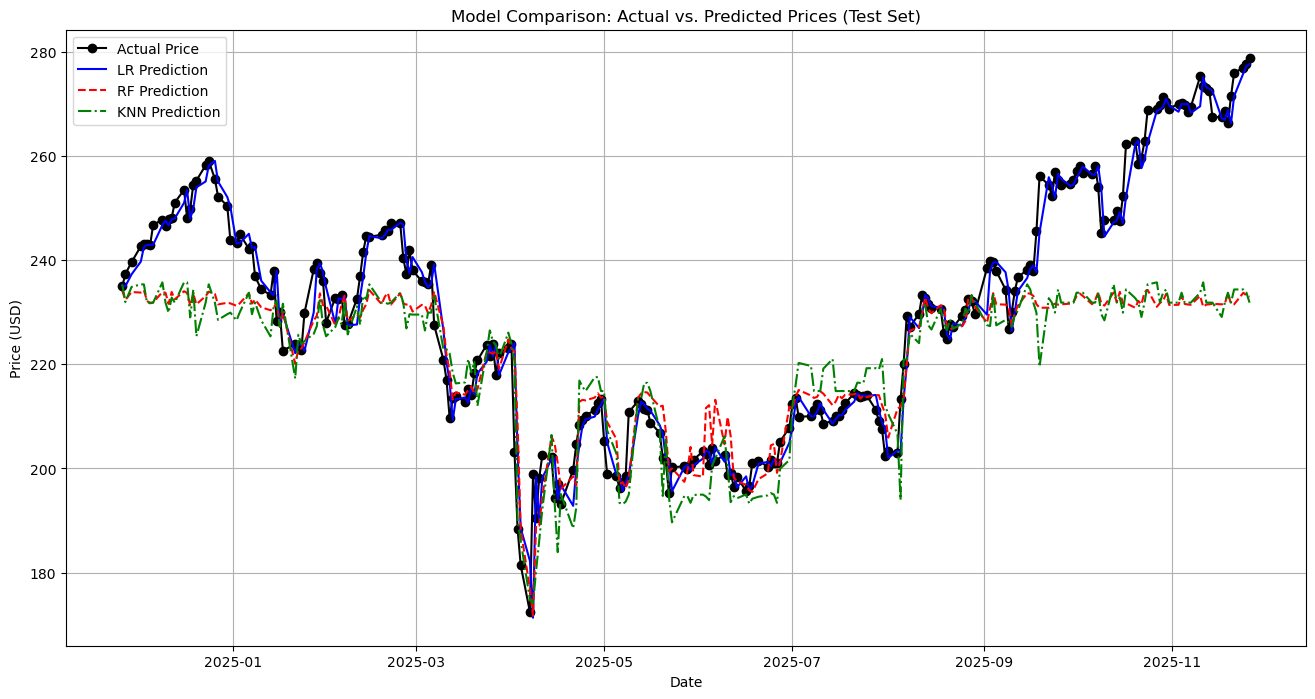

In [28]:
df_summary = pd.DataFrame({
    'Actual Price': y_test,
    'LR Prediction': predictions['Linear Regression'],
    'RF Prediction': predictions['Random Forest Regressor'],
    'KNN Prediction': predictions['K-Nearest Neighbors (KNN)']
}, index=df.tail(len(y_test)).index)

plt.figure(figsize=(16, 8))
plt.plot(df_summary.index, df_summary['Actual Price'], label='Actual Price', marker='o', color='black')
plt.plot(df_summary.index, df_summary['LR Prediction'], label='LR Prediction', linestyle='-', color='blue')
plt.plot(df_summary.index, df_summary['RF Prediction'], label='RF Prediction', linestyle='--', color='red')
plt.plot(df_summary.index, df_summary['KNN Prediction'], label='KNN Prediction', linestyle='-.', color='green')

plt.title('Model Comparison: Actual vs. Predicted Prices (Test Set)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

##  Next Day Prediction

In [29]:


# 1. Identify the best model based on R2 score
best_model_name = max(results, key=lambda k: results[k]['R2'])
best_model = models[best_model_name]

# Get the last row of the original cleaned data (which has no target price)
last_data_point = X[-1].reshape(1, -1)

# Scale this single data point using the fit scaler
last_data_point_scaled = scaler.transform(last_data_point)

# 2. Predict using the best model
final_pred = best_model.predict(last_data_point_scaled)[0]

# 3. Determine the date for the prediction
last_date = df.index[-1]
next_date = last_date + pd.Timedelta(days=1)

print(f"--- NEXT DAY PRICE PREDICTION ---")
print(f"Best Model Used: **{best_model_name}** (R2: {results[best_model_name]['R2']:.4f})")
print(f"Last Known Price: ${df['Price'].iloc[-1]:.2f}")
print(f"Predicted Price on {next_date.strftime('%Y-%m-%d')}: **${final_pred:.2f}**")

--- NEXT DAY PRICE PREDICTION ---
Best Model Used: **Linear Regression** (R2: 0.9651)
Last Known Price: $277.55
Predicted Price on 2025-11-27: **$277.63**


# Conclusion and Business Summary (Adaptive for Any Stock)

In [30]:


# ----------------- Dynamic Interpretation Logic -----------------

# Gather Key Data Points (already calculated in Cell 10)
last_price = df['Price'].iloc[-1]
predicted_price = final_pred 
price_change = predicted_price - last_price
direction = "increase" if price_change > 0 else "decrease"

best_model_name = max(results, key=lambda k: results[k]['R2'])
best_r2 = results[best_model_name]['R2']

# 1. Interpret Confidence Level based on R-squared (R2)
if best_r2 >= 0.8:
    confidence_level = "Very High"
    confidence_description = "The model's predictions closely mirror the actual price movements."
elif best_r2 >= 0.6:
    confidence_level = "Good"
    confidence_description = "The model is reliable for forecasting, but some caution is advised."
elif best_r2 >= 0.4:
    confidence_level = "Fair"
    confidence_description = "The model provides acceptable results, but optimization is recommended."
else:
    confidence_level = "Low"
    confidence_description = "The model's performance suggests it is not suitable for this data without significant tuning or feature engineering."

# 2. Dynamic Model Description (for non-domain understanding)
model_type = "linear" if "Linear" in best_model_name else "tree-based (non-linear)"

# ----------------- Print the Adaptive Summary -----------------

print("="*75)
print("              ADAPTIVE STOCK PRICE PREDICTION SUMMARY")
print("="*75)

# 1. Model Accuracy Summary
print("\n[ MODEL ACCURACY & CONFIDENCE ]")
print(f"The analysis identified the **{best_model_name}** model as the best predictor.")
print(f"This is a {model_type} model.")
print(f"Its R-squared value was **{best_r2:.4f}** ({best_r2*100:.1f}%), indicating a **{confidence_level}** confidence level.")
print(f"Conclusion: {confidence_description}")

# 2. Prediction Outcome
print("\n[ NEXT-DAY FORECAST ]")
print(f"The Last Known Price was **${last_price:.2f}**.")
print(f"The Predicted Price for the next trading day ({next_date.strftime('%Y-%m-%d')}) is **${predicted_price:.2f}**.")
print(f"The forecast suggests the price will **{direction}** by **${abs(price_change):.2f}**.")

print("-" * 75)

              ADAPTIVE STOCK PRICE PREDICTION SUMMARY

[ MODEL ACCURACY & CONFIDENCE ]
The analysis identified the **Linear Regression** model as the best predictor.
This is a linear model.
Its R-squared value was **0.9651** (96.5%), indicating a **Very High** confidence level.
Conclusion: The model's predictions closely mirror the actual price movements.

[ NEXT-DAY FORECAST ]
The Last Known Price was **$277.55**.
The Predicted Price for the next trading day (2025-11-27) is **$277.63**.
The forecast suggests the price will **increase** by **$0.08**.
---------------------------------------------------------------------------
